# 00 · Beijing PM2.5 — Data Acquisition & Cleaning

## Part 0 — Acquire & Clean (Beijing PM2.5)

Five years of **hourly air-pollution** readings from the US Embassy in Beijing (2010–2014): the
target **`pm25`** (PM2.5 concentration, µg/m³) plus weather (temperature, dew point, pressure, wind,
snow, rain). What makes this dataset different from the other two practices is **real missing data**
— and it's *structured*, which is the whole point.

A crucial distinction this notebook establishes:
- the **timeline is complete** (5 years × hourly = 43,824 rows, no missing *rows*),
- but the **`pm25` *values* have 2,067 gaps** (the sensor went down) — missing **values**, not rows.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)


setup ok | numpy 2.1.3 | pandas 2.3.3


### 1. First look — only `pm25` is missing

In [2]:
raw = data.load_raw()
print("raw shape:", raw.shape)
print("\nmissing per column:"); print(raw.isna().sum()[lambda s: s > 0].to_string(), "(only pm2.5)")
print("\nis the timeline complete? rows =", len(raw), "| 5 years of hourly =", 5*365*24 + 24, "(2012 leap)")

raw shape: (43824, 13)

missing per column:
pm2.5    2067 (only pm2.5)

is the timeline complete? rows = 43824 | 5 years of hourly = 43824 (2012 leap)


### 2. The shape of the missingness

*How* values are missing matters as much as *how many*. We measure the **gap runs** — lengths of
consecutive missing hours. The result: mostly **short** gaps (a stray hour here and there, easily
filled) but a handful of **long sensor outages** — the longest **155 hours** (~6.5 days), which no
simple interpolation can honestly fill.

pm25 missing: 2067 (4.7%) across 214 separate gaps
gap length: median 1 h | 90th pct 24 h | max 155 h
single-hour gaps: 112 | gaps > 24h: 20


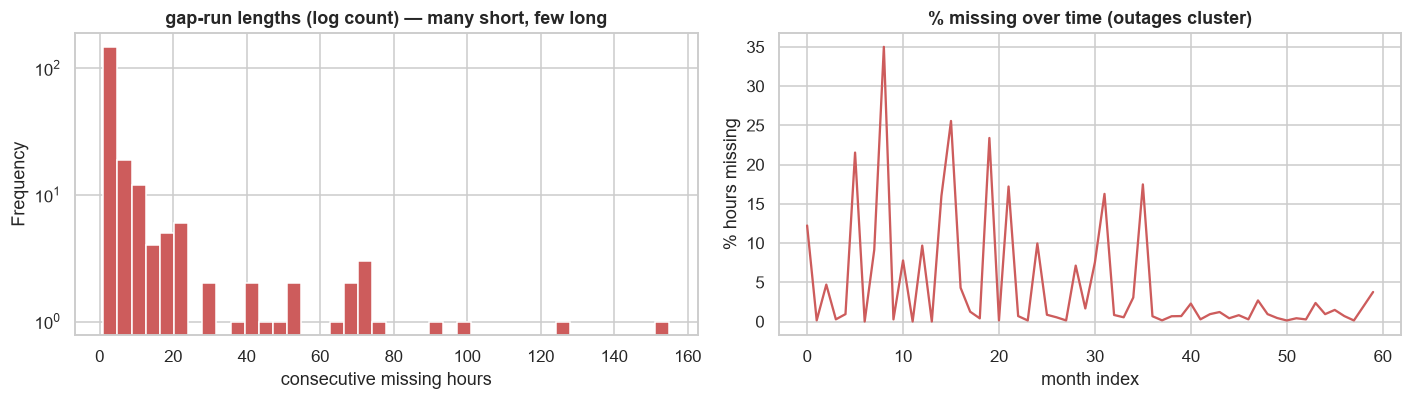

In [3]:
df0 = data.clean()
runs = data.gap_runs(df0["pm25"])
print("pm25 missing: %d (%.1f%%) across %d separate gaps" % (df0.pm25.isna().sum(), 100*df0.pm25.isna().mean(), len(runs)))
print("gap length: median %d h | 90th pct %d h | max %d h" % (runs.median(), runs.quantile(.9), runs.max()))
print("single-hour gaps: %d | gaps > 24h: %d" % ((runs==1).sum(), (runs>24).sum()))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
runs.plot.hist(bins=40, ax=ax[0], color="indianred"); ax[0].set_yscale("log"); ax[0].set_title("gap-run lengths (log count) — many short, few long"); ax[0].set_xlabel("consecutive missing hours")
miss_by_month = df0.pm25.isna().groupby([df0.index.year, df0.index.month]).mean()
ax[1].plot(range(len(miss_by_month)), miss_by_month.values*100, color="indianred"); ax[1].set_title("% missing over time (outages cluster)"); ax[1].set_xlabel("month index"); ax[1].set_ylabel("% hours missing")
fig.tight_layout(); eda.savefig(fig, "p0_missing.png"); plt.show()

### 3. Clean it
`data.clean()` builds a datetime index from the year/month/day/hour columns, renames `pm2.5 → pm25`
and `cbwd → wind_dir`, drops the row counter, and makes wind direction categorical. The `pm25` gaps
are **kept as NaN** on purpose — handling them is a deliberate, evaluated step later, not an
afterthought.

In [4]:
df = data.clean()
print("clean:", df.shape, "| index", df.index.min(), "->", df.index.max(), "| freq", df.index.freq)
print("wind direction:", df.wind_dir.value_counts().to_dict(), "(cv = calm/variable)")
df.head(3)

clean: (43824, 8) | index 2010-01-01 00:00:00 -> 2014-12-31 23:00:00 | freq <Hour>
wind direction: {'SE': 15290, 'NW': 14150, 'cv': 9387, 'NE': 4997} (cv = calm/variable)


,pm25,DEWP,TEMP,PRES,wind_dir,Iws,Is,Ir
datetime,,,,,,,,
2010-01-01 00:00:00,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,NaN,-21,-11.0,1019.0,NW,6.71,0,0


### 4. Persist

In [5]:
data.build_processed()
print("wrote data/processed/beijing_clean.csv — Part 0 complete (gaps preserved for Part 2).")

wrote data/processed/beijing_clean.csv — Part 0 complete (gaps preserved for Part 2).
